<a href="https://colab.research.google.com/github/sarahbiotech/A-Comparative-Study-of-Machine-Learning-Algorithms-for-Diabetes-Risk-Prediction/blob/main/diabetes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  Outcome  
0                       0.627   50        1  
1                  

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()
Accuracy is: 0.7532467532467533 f1_score is: 0.5957446808510638 Recall is : 0.5283018867924528 confusion is: [[88 13]
 [25 28]]


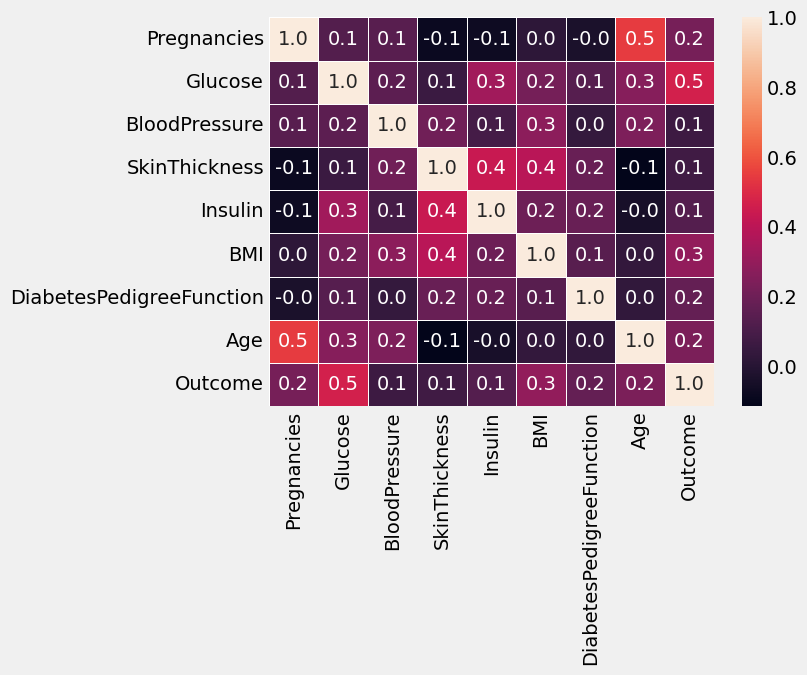

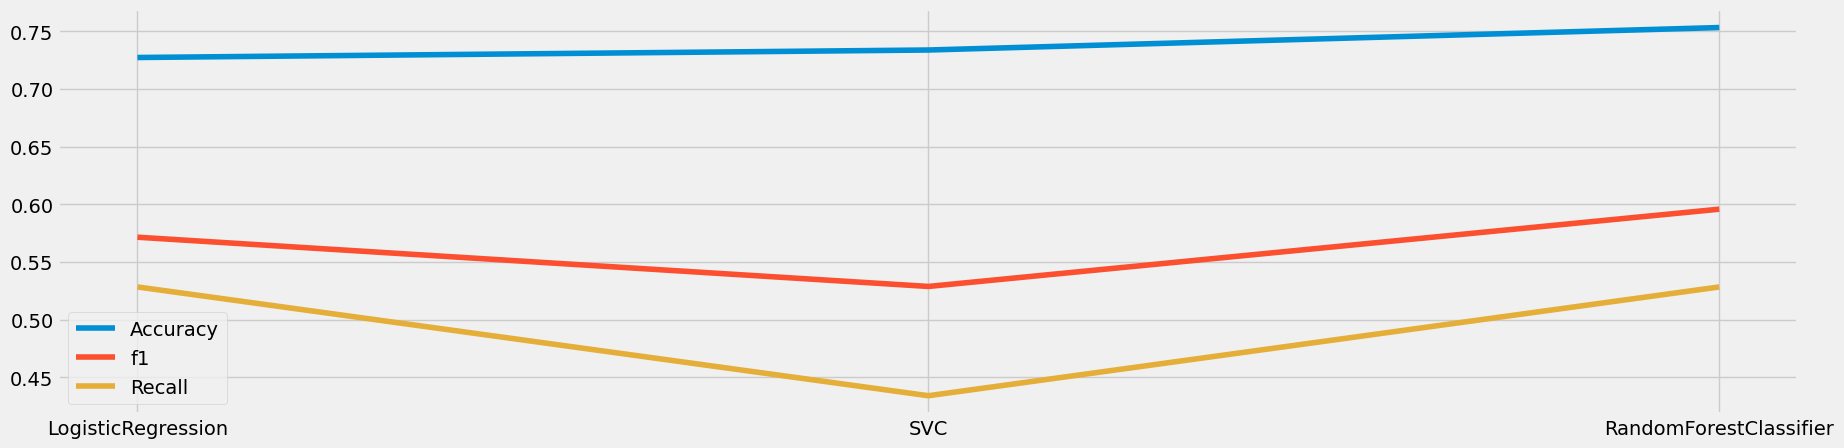

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [74]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
import joblib
plt.style.use('fivethirtyeight')

#---------Reading data.......#

import os
os.listdir('/content')

df= pd.read_csv('/content/diabetes.csv')
df.describe()
print(df)

#...............Analysis............#
df.corr()
sns.heatmap(df.corr(),annot=True,fmt="0.1f",linewidth=.5)

#----------Model.........#
x= df.drop('Outcome',axis=1)
y= df['Outcome']
x_train,x_test,y_train,y_test= train_test_split(x,y,test_size=0.2, random_state=20)
model1= LogisticRegression()
model2= SVC()
model3= RandomForestClassifier()
columns=['LogisticRegression','SVC','RandomForestClassifier']
result1=[]
result2=[]
result3=[]



def cal(model):
    model.fit(x_train,y_train)
    pre= model.predict(x_test)
    accuracy= accuracy_score(y_test,pre)
    f1= f1_score(y_test,pre)
    recal= recall_score(y_test,pre)
    confusion= confusion_matrix(y_test,pre)
    result1.append(accuracy)
    result2.append(f1)
    result3.append(recal)
    print(model)
    print('Accuracy is:',accuracy, 'f1_score is:',f1, 'Recall is :',recal,'confusion is:',confusion)

cal(model3)
cal(model2)
cal(model1)
result1
result2
result3
final_result= pd.DataFrame({'Algorithm':columns,'accuracy':result1,'f1':result2,'recal':result3})
fig,ax= plt.subplots(figsize=(20,5))
plt.plot(final_result.Algorithm, result1,label="Accuracy")
plt.plot(final_result.Algorithm, result2,label="f1")
plt.plot(final_result.Algorithm, result3, label="Recall")
plt.legend()
plt.show()
#...................model saving..........#

joblib.dump(model1, 'logistic_model.pkl')
joblib.dump(model2, 'svm_model.pkl')
joblib.dump(model3, 'random_forest_model.pkl')

from google.colab import files

files.download('logistic_model.pkl')
files.download('svm_model.pkl')
files.download('random_forest_model.pkl')
